In [34]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

In [35]:
df = pd.read_csv(Path("../raw_data/Loan_default.csv"))

print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

df.info()

print(df.isna().sum().sort_values(ascending=False).head(10))

display(df.describe().T.head(10))

Rows: 255347
Columns: 18


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


Split data into features and target (Also dropped LoanID because it doesnt contribute to analysis)

In [36]:
X = df.drop(columns=["LoanID", "Default"])
y = df["Default"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

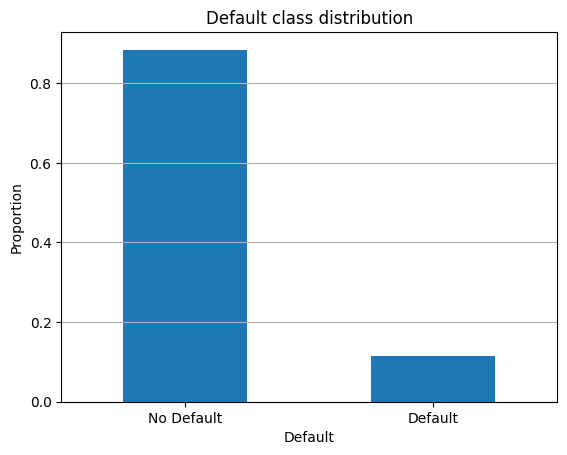

In [40]:
y_train.value_counts(normalize=True).plot(kind="bar", title="Default class distribution")
plt.xticks(ticks=[0,1], labels=["No Default", "Default"], rotation=0)
plt.ylabel("Proportion")
plt.grid(axis="y")
plt.show()

In [38]:
def preprocess_data(X: pd.DataFrame) -> ColumnTransformer:
    """
    Builds a ColumnTransformer that applies:
    - Robust/Standard scaling for numerical columns
    - Ordinal encoding for ordinal/binary categories
    - OneHot encoding for nominal categories
    """

    # === Feature Groups ===

    # Numeric (Robust scaling: skewed or wide-range)
    robust_numeric = ["Income", "LoanAmount", "MonthsEmployed"]

    # Numeric (Standard scaling)
    standard_numeric = ["Age", "CreditScore", "InterestRate", "DTIRatio"]

    # Ordinal categorical (natural order or few integers)
    ordinal_cats = ["LoanTerm", "NumCreditLines", "HasMortgage", "HasDependents", "HasCoSigner"]

    # Nominal categorical (no order, low cardinality)
    onehot_cats = ["Education", "EmploymentType", "MaritalStatus", "LoanPurpose"]

    # === Pipelines ===

    robust_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", RobustScaler())
    ])

    standard_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])

    ordinal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder())
    ])

    onehot_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    # === ColumnTransformer ===

    preprocessor = ColumnTransformer(transformers=[
        ("robust_num", robust_pipeline, robust_numeric),
        ("standard_num", standard_pipeline, standard_numeric),
        ("ordinal_cat", ordinal_pipeline, ordinal_cats),
        ("onehot_cat", onehot_pipeline, onehot_cats)
    ])

    return preprocessor

In [39]:
preprocessor = preprocess_data(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (191510, 28)
Test shape: (63837, 28)


### RANDOMFORESTCLASSIFIER TEST

In [ ]:
# Build pipeline
pipeline = Pipeline([
    ("preprocessor", preprocess_data(X_train)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Report
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.887     0.998     0.939     56410
           1      0.667     0.033     0.062      7427

    accuracy                          0.886     63837
   macro avg      0.777     0.515     0.501     63837
weighted avg      0.861     0.886     0.837     63837



### MOST IMPORTANT FEATURES

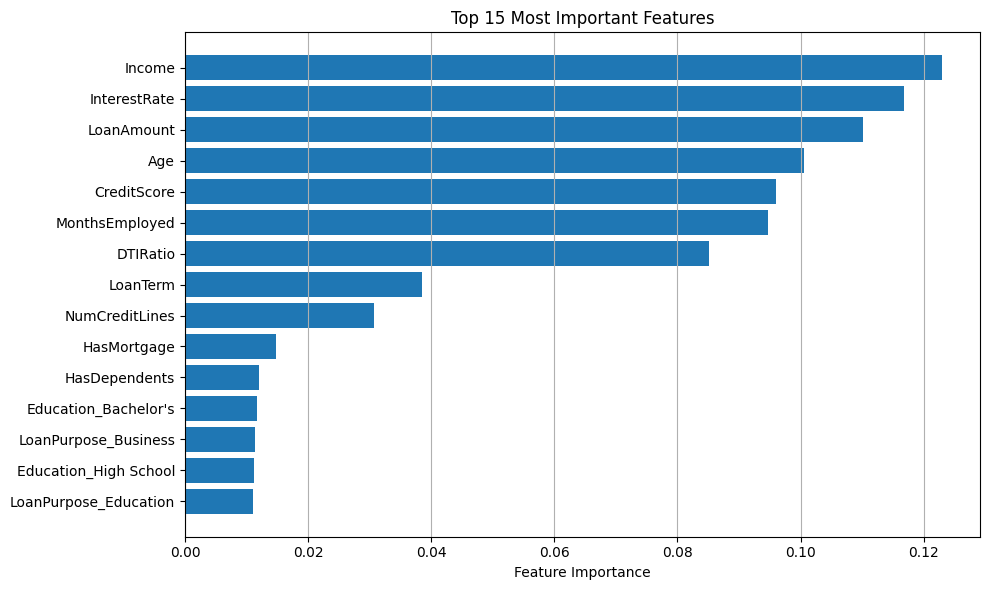

In [44]:
model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocessor"]

# Get original column names (grouped as you defined in preprocess_data)
robust_features = preprocessor.transformers_[0][2]
standard_features = preprocessor.transformers_[1][2]
ordinal_features = preprocessor.transformers_[2][2]

# Get names of one-hot encoded columns
onehot_encoder = preprocessor.named_transformers_["onehot_cat"].named_steps["encoder"]
onehot_input_cols = preprocessor.transformers_[3][2]
onehot_feature_names = onehot_encoder.get_feature_names_out(onehot_input_cols)

# Combine all feature names into one list (in order of how they were processed)
all_feature_names = np.concatenate([
    robust_features,
    standard_features,
    ordinal_features,
    onehot_feature_names
])

# Get the feature importance values from the model
importances = model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]  # indices of features from most to least important

# Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[sorted_indices[:15]][::-1])
plt.yticks(range(15), all_feature_names[sorted_indices[:15]][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [ ]:
for col in X.columns:
    print(f"{col} → {X[col].nunique()} unique values")
    print(X[col].unique()[:10], "\n")

Age → 52 unique values
[56 69 46 32 60 25 38 36 40 28] 

Income → 114620 unique values
[ 85994  50432  84208  31713  20437  90298 111188 126802  42053 132784] 

LoanAmount → 158729 unique values
[ 50587 124440 129188  44799   9139  90448 177025 155511  92357 228510] 

CreditScore → 550 unique values
[520 458 451 743 633 720 429 531 827 480] 

MonthsEmployed → 120 unique values
[ 80  15  26   0   8  18  67  83 114  94] 

NumCreditLines → 4 unique values
[4 1 3 2] 

InterestRate → 2301 unique values
[15.23  4.81 21.17  7.07  6.51 22.72 19.11  8.15 23.94  9.09] 

LoanTerm → 5 unique values
[36 60 24 48 12] 

DTIRatio → 81 unique values
[0.44 0.68 0.31 0.23 0.73 0.1  0.16 0.43 0.2  0.33] 

Education → 4 unique values
["Bachelor's" "Master's" 'High School' 'PhD'] 

EmploymentType → 4 unique values
['Full-time' 'Unemployed' 'Self-employed' 'Part-time'] 

MaritalStatus → 3 unique values
['Divorced' 'Married' 'Single'] 

HasMortgage → 2 unique values
['Yes' 'No'] 

HasDependents → 2 unique val

In [ ]:
X.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,255347.0,NaN,NaN,NaN,43.498306,14.990258,18.0,31.0,43.0,56.0,69.0
Income,255347.0,NaN,NaN,NaN,82499.304597,38963.013729,15000.0,48825.5,82466.0,116219.0,149999.0
LoanAmount,255347.0,NaN,NaN,NaN,127578.865512,70840.706142,5000.0,66156.0,127556.0,188985.0,249999.0
CreditScore,255347.0,NaN,NaN,NaN,574.264346,158.903867,300.0,437.0,574.0,712.0,849.0
MonthsEmployed,255347.0,NaN,NaN,NaN,59.541976,34.643376,0.0,30.0,60.0,90.0,119.0
NumCreditLines,255347.0,NaN,NaN,NaN,2.501036,1.117018,1.0,2.0,2.0,3.0,4.0
InterestRate,255347.0,NaN,NaN,NaN,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,NaN,NaN,NaN,36.025894,16.96933,12.0,24.0,36.0,48.0,60.0
DTIRatio,255347.0,NaN,NaN,NaN,0.500212,0.230917,0.1,0.3,0.5,0.7,0.9
Education,255347,4,Bachelor's,64366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
